In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import sys
sys.path.append('../')
from mlcore.linear_svm import CustomLinearSVM

In [2]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [3]:
X, y = datasets.make_classification(
    n_samples=1_00_000, n_features=4, random_state=4
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

In [4]:
y_train = np.where(y_train <= 0, -1, 1)
y_test = np.where(y_test <= 0, -1, 1)

In [5]:
model = CustomLinearSVM(learning_rate=0.001, n_iters=5000, C=0.01, tol=1e-4, patience=50)
history = model.fit(X_train, y_train)
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f"MSE: {mse:.4f}")

f1 = f1_score(y_test, predictions)
print(f"F1 Score: {f1:.4f}")

precision = precision_score(y_test, predictions)
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test, predictions)
print(f"Recall: {recall:.4f}")

accu = accuracy_score(y_test, predictions)
print(f"Accuracy: {accu:.4f}")

MSE: 0.3756
F1 Score: 0.9067
Precision: 0.8978
Recall: 0.9158
Accuracy: 0.9061


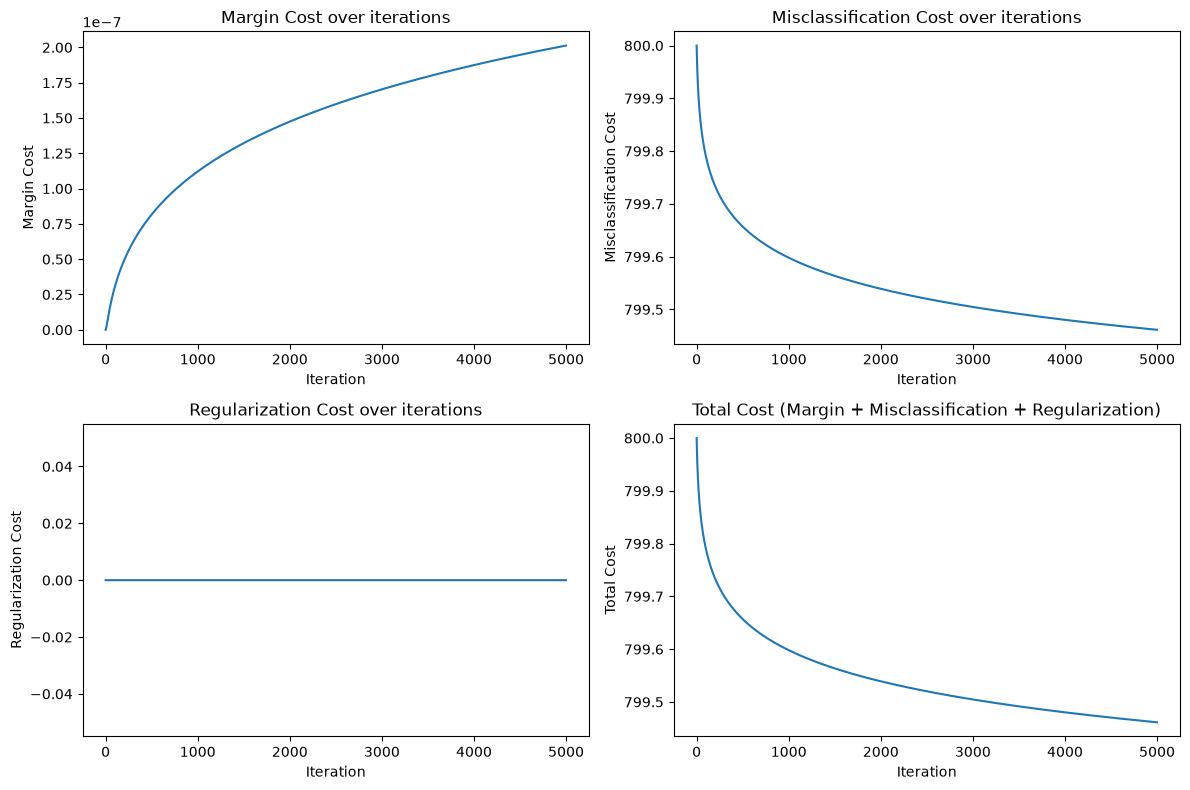

In [6]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history['margin_cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Margin Cost')
plt.title('Margin Cost over iterations')

plt.subplot(2, 2, 2)
plt.plot(history['misclassification_cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Misclassification Cost')
plt.title('Misclassification Cost over iterations')

plt.subplot(2, 2, 3)
plt.plot(history['regularization_history'])
plt.xlabel('Iteration')
plt.ylabel('Regularization Cost')
plt.title('Regularization Cost over iterations')

plt.subplot(2, 2, 4)
plt.plot(history['cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Total Cost')
plt.title('Total Cost (Margin + Misclassification + Regularization)')

plt.tight_layout()
plt.show()

In [7]:
svc = SVC(kernel='linear', C=1.0, random_state=1234)
svc.fit(X_train, y_train)
svc_predictions = svc.predict(X_test)


svc_mse = mean_squared_error(y_test, svc_predictions)
print(f"MSE: {svc_mse:.4f}")

svc_f1 = f1_score(y_test, svc_predictions)
print(f"F1 Score: {svc_f1:.4f}")

svc_precision = precision_score(y_test, svc_predictions)
print(f"Precision: {svc_precision:.4f}")

svc_recall = recall_score(y_test, svc_predictions)
print(f"Recall: {svc_recall:.4f}")

svc_accu = accuracy_score(y_test, svc_predictions)
print(f"Accuracy: {svc_accu:.4f}")

MSE: 0.3682
F1 Score: 0.9082
Precision: 0.9032
Recall: 0.9131
Accuracy: 0.9080


## With regularization

In [12]:
model = CustomLinearSVM(learning_rate=0.1, n_iters=5000, C=0.01, l1=True, alpha=0.01, tol=1e-4, patience=50)
history_l1 = model.fit(X_train, y_train)
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f"MSE: {mse:.4f}")

f1 = f1_score(y_test, predictions)
print(f"F1 Score: {f1:.4f}")

precision = precision_score(y_test, predictions)
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test, predictions)
print(f"Recall: {recall:.4f}")

accu = accuracy_score(y_test, predictions)
print(f"Accuracy: {accu:.4f}")

MSE: 0.3756
F1 Score: 0.9067
Precision: 0.8978
Recall: 0.9158
Accuracy: 0.9061


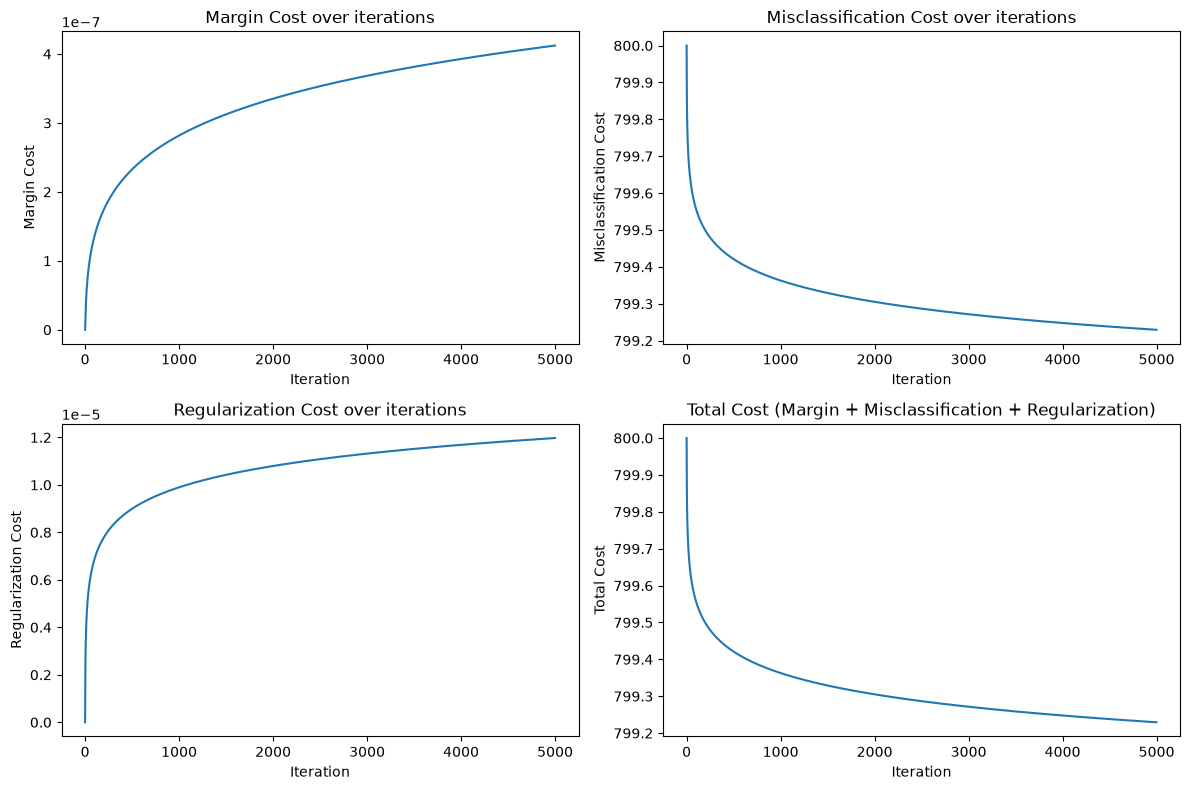

In [13]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history_l1['margin_cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Margin Cost')
plt.title('Margin Cost over iterations')

plt.subplot(2, 2, 2)
plt.plot(history_l1['misclassification_cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Misclassification Cost')
plt.title('Misclassification Cost over iterations')

plt.subplot(2, 2, 3)
plt.plot(history_l1['regularization_history'])
plt.xlabel('Iteration')
plt.ylabel('Regularization Cost')
plt.title('Regularization Cost over iterations')

plt.subplot(2, 2, 4)
plt.plot(history_l1['cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Total Cost')
plt.title('Total Cost (Margin + Misclassification + Regularization)')

plt.tight_layout()
plt.show()

In [16]:
model = CustomLinearSVM(learning_rate=0.1, n_iters=5000, C=0.01, l2=True, alpha=0.01, tol=1e-4, patience=50)
history_l2 = model.fit(X_train, y_train)
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f"MSE: {mse:.4f}")

f1 = f1_score(y_test, predictions)
print(f"F1 Score: {f1:.4f}")

precision = precision_score(y_test, predictions)
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test, predictions)
print(f"Recall: {recall:.4f}")

accu = accuracy_score(y_test, predictions)
print(f"Accuracy: {accu:.4f}")

MSE: 0.3756
F1 Score: 0.9067
Precision: 0.8978
Recall: 0.9158
Accuracy: 0.9061


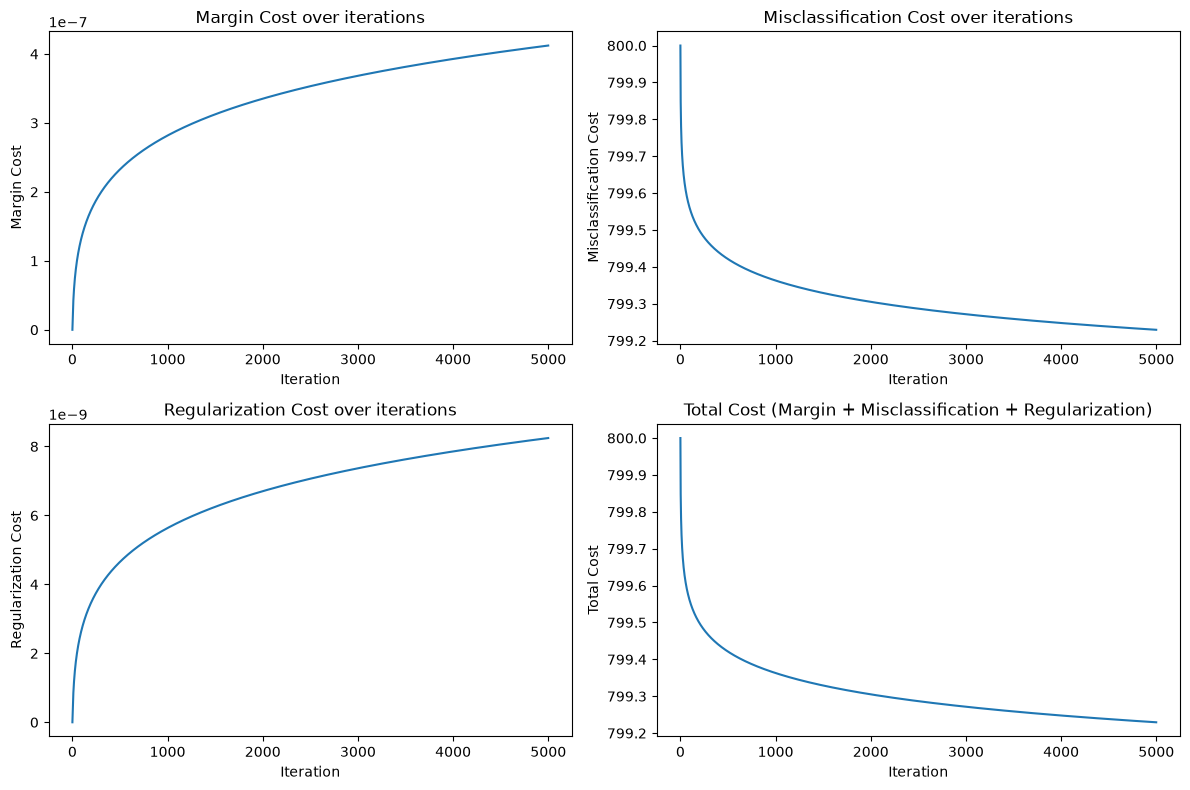

In [17]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history_l2['margin_cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Margin Cost')
plt.title('Margin Cost over iterations')

plt.subplot(2, 2, 2)
plt.plot(history_l2['misclassification_cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Misclassification Cost')
plt.title('Misclassification Cost over iterations')

plt.subplot(2, 2, 3)
plt.plot(history_l2['regularization_history'])
plt.xlabel('Iteration')
plt.ylabel('Regularization Cost')
plt.title('Regularization Cost over iterations')

plt.subplot(2, 2, 4)
plt.plot(history_l2['cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Total Cost')
plt.title('Total Cost (Margin + Misclassification + Regularization)')

plt.tight_layout()
plt.show()